In [1]:
import yfinance as yf
import pandas as pd 
import os
import numpy as np
import seaborn  as sns            # plots
import matplotlib.pyplot as plt   # plots
import plotly.graph_objects as go
from datetime import date,timedelta,datetime
import warnings
warnings.filterwarnings("ignore")


c:\ProgramData\Anaconda3\envs\trading\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\ProgramData\Anaconda3\envs\trading\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def LoadData(ticker):
    #yfinance.Ticker.history() method returns the adjusted prices by default, accounting for stock splits and dividends
    #and other corporate actions. The Close column represents the adjusted close price when auto_adjust=True. 
    # You need to set auto_adjust=False to get the raw close prices.
    filename = ticker.replace("^", "")
    if os.path.exists(f"data/{filename}.csv"):
        df = pd.read_csv(f"data/{filename}.csv", index_col='Date', parse_dates=True)
    else:
        df = yf.download(ticker, period="max",auto_adjust=False)
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
        df.to_csv(f"data/{filename}.csv")
    return df

## Introduction Ackermans & van Haaren

Ackermans & van Haaren (ACKB - ISIN code:[BE0003764785](https://live.euronext.com/nl/product/equities/BE0003764785-XBRU/market-information) and [Yahoo Finance ticker: ACKB.BR](https://finance.yahoo.com/quote/ACKB.BR/)) is a holding company listed on Euronext Brussels since June 1984. On Yahoo Finance you will find the historical prices starting from January 2000.

In [6]:
data = LoadData("ACKB.BR")
data.head()

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2000-01-04,16.570818,29.150000,30.000000,29.150000,30.000000,13618
2000-01-05,16.599237,29.200001,29.490000,28.700001,29.020000,16085
2000-01-06,16.144468,28.400000,29.200001,28.250000,28.750000,18330
2000-01-07,16.349117,28.760000,28.900000,28.400000,28.700001,9565
2000-01-10,16.144468,28.400000,28.900000,28.150000,28.700001,10370


In [7]:
data.describe()

,Adj Close,Close,High,Low,Open,Volume
count,6873.000000,6873.000000,6873.000000,6873.000000,6873.000000,6873.000000
mean,81.076802,95.369758,96.159120,94.579617,95.403720,27576.347301
std,62.448354,61.328156,61.726711,60.920640,61.318617,20664.404093
min,7.418988,12.520000,12.750000,12.500000,12.520000,0.000000
25%,31.793385,46.959999,47.509998,46.169998,47.000000,16162.000000
50%,53.150398,70.480003,71.000000,70.029999,70.500000,24042.000000
75%,123.784996,141.800003,142.899994,140.800003,141.899994,34121.000000
max,293.011658,298.000000,300.200012,292.600006,296.799988,535556.000000


In [9]:
#Create fill similar to the Yahoo Finance mountain plot
filtered_data = data[data.index >= pd.Timestamp('2006-02-01')]
fig = go.Figure()
fig.add_trace(go.Scatter(x=filtered_data.index, y=filtered_data['Close'], mode='lines', name='ACKB.BR Close Price', line=dict(color='green', width=2), fill='tozeroy', fillcolor='rgba(0, 128, 0, 0.3)'))
fig.update_layout(
    title='Ackermans & Van Haaren Close Price',
    xaxis_title='Date',
    yaxis_title='Close Price',
    xaxis=dict(
        tickformat='%b %Y',
        dtick='M12',  # Yearly ticks
        showgrid=False
    ),
    yaxis=dict(showgrid=False),
    showlegend=True,
    width=1200,
    height=600,
    template='plotly_white'
)
fig.show()

## Visualize yearly returns Ackermans & van Haaren

### Transform data to yearly returns

In [10]:
# Calculate yearly returns using Close and Adj Close
yearly_data = data.resample('Y').last()
yearly_returns_close = yearly_data['Close'].pct_change()*100
yearly_returns_close = yearly_returns_close.round(2)
yearly_returns_adj_close = yearly_data['Adj Close'].pct_change()*100

# Create a dataframe with yearly returns
yearlyreturns = pd.DataFrame({
    'Year': yearly_returns_close.index.year,
    'Close_Returns': yearly_returns_close.values,
    'Adj_Close_Returns': yearly_returns_adj_close.values
})

print("Yearly Returns DataFrame:")
print(yearlyreturns)

Yearly Returns DataFrame:
    Year  Close_Returns  Adj_Close_Returns
0   2000            NaN                NaN
1   2001          -8.47          -7.346524
2   2002         -40.74         -39.722812
3   2003          -1.42           1.874137
4   2004          48.70          52.894156
5   2005          78.29          82.007898
6   2006          36.96          39.179434
7   2007           6.35           8.041246
8   2008         -45.67         -44.569695
9   2009          42.83          47.217132
10  2010          18.83          26.272695
11  2011          -6.70          -4.482884
12  2012           7.15          10.026634
13  2013          37.89          41.291966
14  2014          19.89          22.135426
15  2015          32.17          34.136777
16  2016          -2.11          -0.419834
17  2017           9.88          11.386687
18  2018          -9.20          -7.830991
19  2019           5.99           7.818424
20  2020         -11.95         -10.209511
21  2021          37.15     

In [11]:
# Pivot the yearlyreturns dataframe to have years as columns
# First, melt the dataframe
melted = yearlyreturns.melt(id_vars='Year', var_name='Return_Type', value_name='Return_Value')

# Then pivot to have Return_Type as index and Year as columns
pivot_returns = melted.pivot(index='Return_Type', columns='Year', values='Return_Value')

# Remove columns with NaN values
pivot_returns = pivot_returns.dropna(axis=1)

print("Pivoted DataFrame with Years as Columns:")
print(pivot_returns.loc[['Close_Returns']])

Pivoted DataFrame with Years as Columns:
Year           2001   2002  2003  2004   2005   2006  2007   2008   2009  \
Return_Type                                                                
Close_Returns -8.47 -40.74 -1.42  48.7  78.29  36.96  6.35 -45.67  42.83   

Year            2010  ...  2017  2018  2019   2020   2021  2022  2023   2024  \
Return_Type           ...                                                      
Close_Returns  18.83  ...  9.88  -9.2  5.99 -11.95  37.15 -5.04 -0.87  19.96   

Year            2025   2026  
Return_Type                  
Close_Returns  21.78  14.14  

[1 rows x 26 columns]


In [ ]:
# Calculate returns for 1, 3, 5, and 10 calendar years
def calculate_returns(data, years):
    prices = data['Close'].dropna().sort_index()
    returns = {}
    if prices.empty:
        return {f'{year}_year_return': np.nan for year in years}

    end_date = prices.index[-1]
    end_price = prices.iloc[-1]
    for year in years:
        target_date = end_date - pd.DateOffset(years=year)
        start_prices = prices.loc[:target_date]
        if not start_prices.empty:
            returns[f'{year}_year_return'] = round((end_price / start_prices.iloc[-1] - 1) * 100, 2)
        else:
            returns[f'{year}_year_return'] = np.nan
    return returns


def calculate_annualized_returns(data, years=(1, 2, 3, 5, 10)):
    prices = data['Close'].dropna().sort_index()
    returns = {}
    if prices.empty:
        return {f'{year}_year_annualized_return': np.nan for year in years}

    end_date = prices.index[-1]
    end_price = prices.iloc[-1]
    for year in years:
        target_date = end_date - pd.DateOffset(years=year)
        start_prices = prices.loc[:target_date]
        if not start_prices.empty:
            start_price = start_prices.iloc[-1]
            if start_price > 0 and end_price > 0:
                returns[f'{year}_year_annualized_return'] = round(((end_price / start_price) ** (1 / year) - 1) * 100, 2)
            else:
                returns[f'{year}_year_annualized_return'] = np.nan
        else:
            returns[f'{year}_year_annualized_return'] = np.nan
    return returns


print("Calculating returns for 1, 3, 5, and 10 years:")
print(calculate_returns(data, [1, 3, 5, 10]))
print("Calculating annualized returns for 1, 2, 3, 5, and 10 years:")
print(calculate_annualized_returns(data))

Calculating returns for 1, 3, 5, and 10 years:
{'1_year_return': 21.47, '3_year_return': 85.05, '5_year_return': 77.84, '10_year_return': 124.5}


### Plot ACKB.BR yearly returns using bar chart

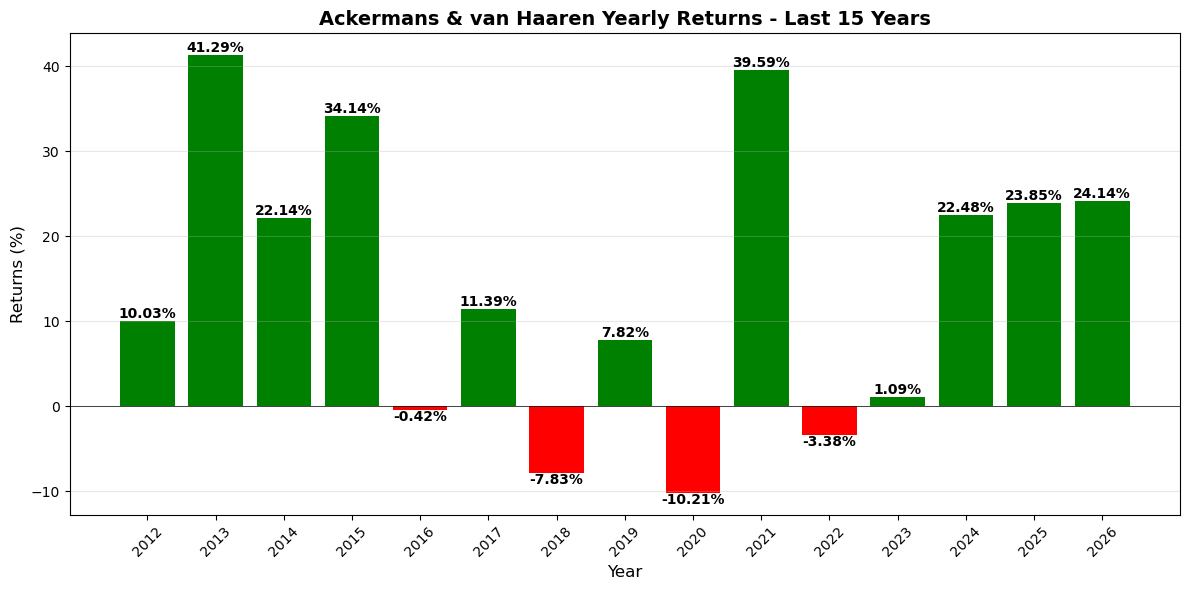


Yearly Returns Summary (Last 10 Years):
    Year  Adj_Close_Returns
12  2012          10.026620
13  2013          41.292010
14  2014          22.135394
15  2015          34.136779
16  2016          -0.419841
17  2017          11.386695
18  2018          -7.830992
19  2019           7.818416
20  2020         -10.209514
21  2021          39.591621
22  2022          -3.376774
23  2023           1.085857
24  2024          22.475283
25  2025          23.850774
26  2026          24.137931


In [9]:
# Bar plot of yearly returns for the last 15 years
plt.figure(figsize=(12, 6))

subset = yearlyreturns.tail(15).copy()
subset['Year'] = subset['Year'].astype(str)

# Create bar plot
bars = plt.bar(subset['Year'], subset['Adj_Close_Returns'], color=['green' if x > 0 else 'red' for x in subset['Adj_Close_Returns']])

# Add data labels on each bar
for bar, value in zip(bars, subset['Adj_Close_Returns']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%',
             ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Returns (%)', fontsize=12)
plt.title('Ackermans & van Haaren Yearly Returns - Last 15 Years', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nYearly Returns Summary (Last 10 Years):")
print(subset[['Year', 'Adj_Close_Returns']])

### ACKB Dividend history

Ackermans & Van Haaren has a long record of steadily growing dividends. Ex-dividend date for ACKB in 2026 - May 28, 2026. If you look at the dividend data for the last 10 year that you can retrieve using the Yahoo Finance API - you will see that  net dividend has grown from 1.96 EUR in 2016 to 3.8 EUR in 2025 (assuming the standard 30% dividend tax in Belgium )


### Retrieve ticker data and the price at the ex-dividend date

In [10]:
tck= yf.Ticker('ACKB.BR')

start_date = "2016-01-01"  
df= tck.dividends[start_date:].to_frame()
print(df)

                           Dividends
Date                                
2016-05-30 00:00:00+02:00       1.96
2017-05-29 00:00:00+02:00       2.04
2018-05-30 00:00:00+02:00       2.20
2019-06-03 00:00:00+02:00       2.32
2020-11-11 00:00:00+01:00       2.32
2021-05-27 00:00:00+02:00       2.35
2022-05-30 00:00:00+02:00       2.75
2023-05-29 00:00:00+02:00       3.10
2024-05-30 00:00:00+02:00       3.40
2025-05-29 00:00:00+02:00       3.80
2026-05-28 00:00:00+02:00       4.60


In [11]:
prices = [] 

for index,row in df.iterrows():
    tckdate = datetime.strptime(str(index),'%Y-%m-%d %H:%M:%S%z').date()
    try:
        price = tck.history(start=tckdate,interval='1d')['Close'][0]
    except:
        price = None
    prices.append(price)    

df['Price'] = prices
df['DividendYield'] = (df['Dividends'] / df['Price']).round(4) * 70

r_df= df.resample('Y').agg('sum')

C:\Users\jop_x\AppData\Local\Temp\ipykernel_15788\3596100457.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\jop_x\AppData\Local\Temp\ipykernel_15788\3596100457.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\jop_x\AppData\Local\Temp\ipykernel_15788\3596100457.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\jop_x\AppData\Local\Temp\ipykernel_15788\3596100457.py:6: FutureWarning:

Series.__getit

### Visualize the net dividend and dividend yield

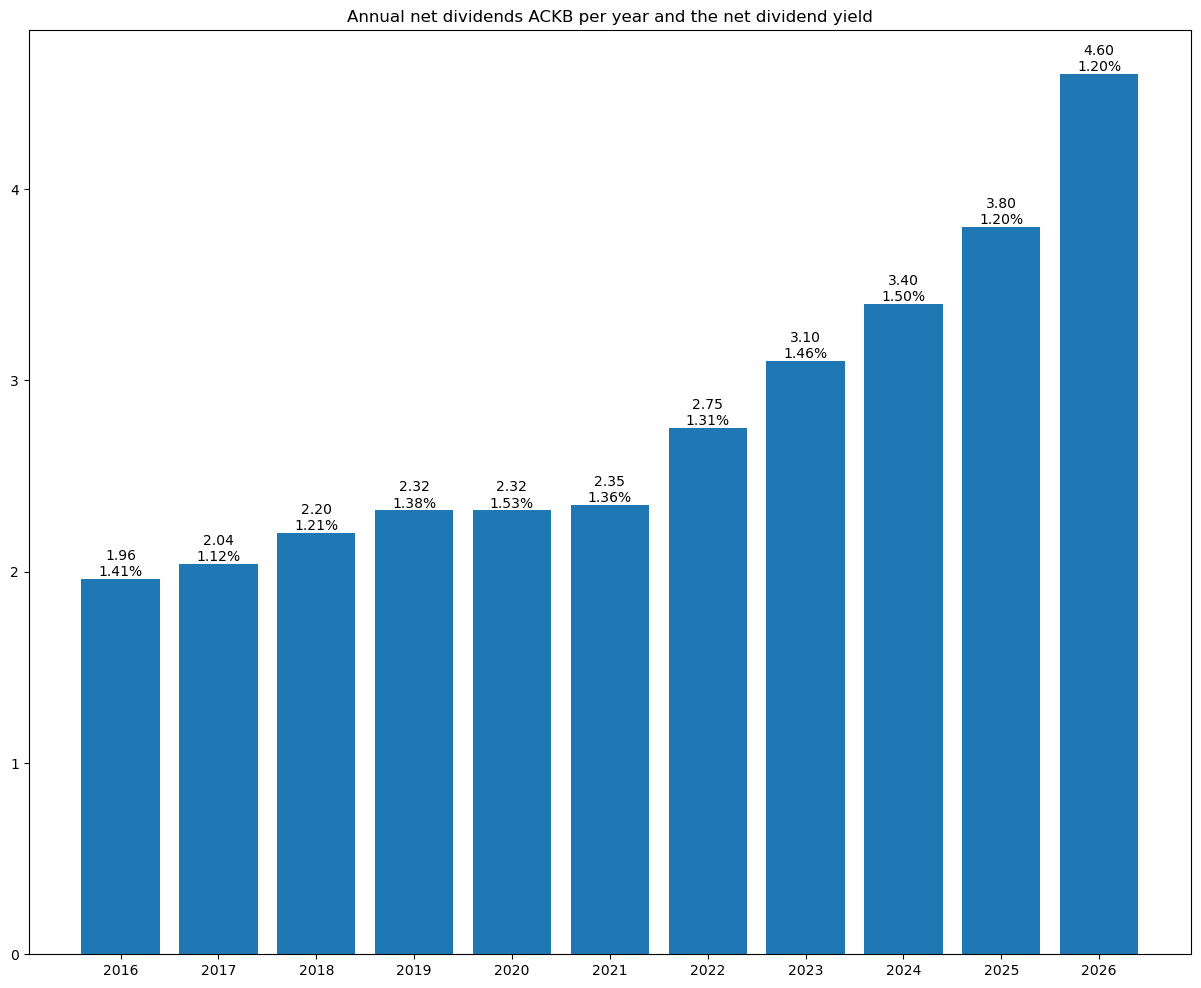

Total net dividends 30.839999999999996 


In [12]:
columns = r_df.columns
r_df['Year'] = r_df.index.year

plt.figure(figsize=(15,12))
bars= plt.bar(r_df['Year'], r_df['Dividends'])
plt.xticks(r_df['Year'])
plt.title("Annual net dividends ACKB per year and the net dividend yield")  


# Add both net dividend and dividend yield as labels
for bar, (_, row) in zip(bars, r_df.iterrows()):
    yval = bar.get_height()
    yield_val = row['DividendYield']
    label = f"{yval:.2f}\n{yield_val:.2f}%"
    plt.text(bar.get_x() + bar.get_width()/2, yval, label, ha='center', va='bottom')

plt.show()

totaldiv = r_df['Dividends'].sum()

print(f"Total net dividends {totaldiv} ")